In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.model_selection import GridSearchCV
from sklearn.neural_network import MLPClassifier

from xgboost import XGBClassifier
from sklearn.ensemble import VotingClassifier
from sklearn.model_selection import RandomizedSearchCV

In [2]:
data = pd.read_csv("diabetes.csv")
data

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [4]:
data.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


<body>Correlation plot of independent variables</body>

Text(0.5, 1.0, 'Correlation heatmap')

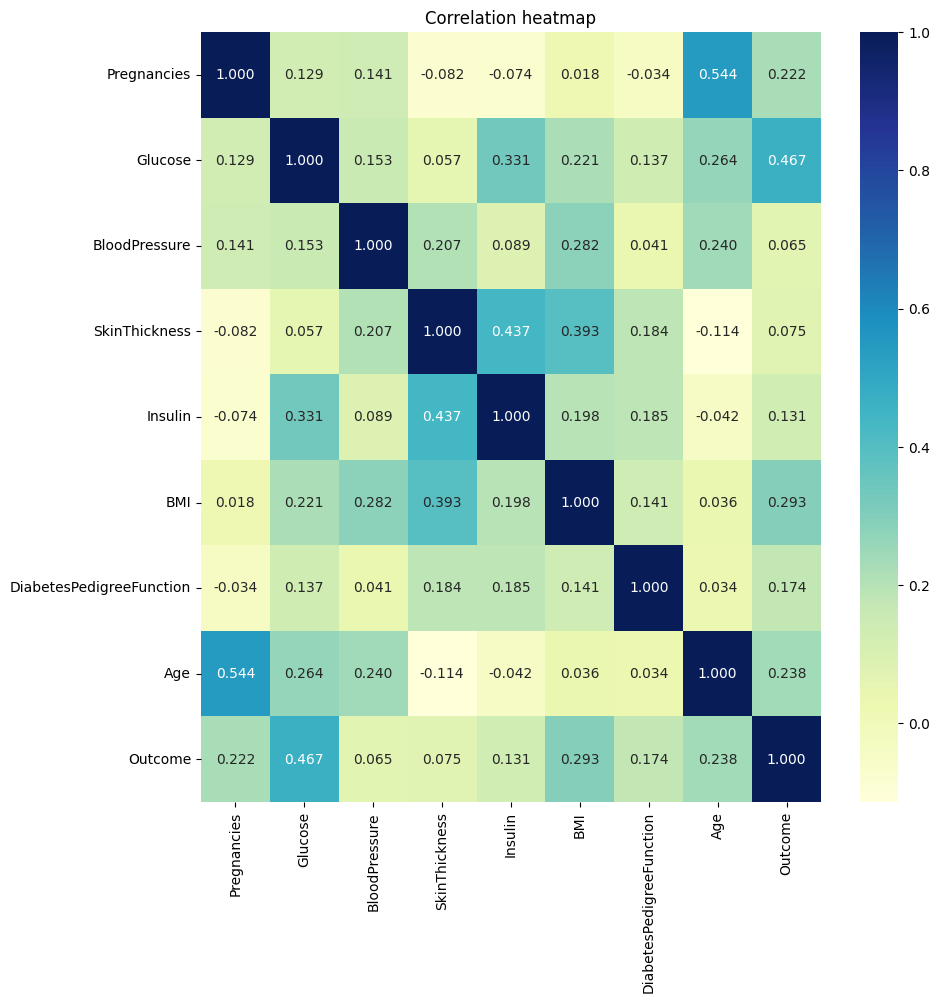

In [5]:
plt.figure(figsize=(10, 10))
sns.heatmap(data.corr(), annot=True, fmt=".3f", cmap="YlGnBu")
plt.title("Correlation heatmap")

<body>Exploring Pregnancy and target variables</body>

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24036\1238410465.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kde = sns.kdeplot(data["Pregnancies"][data["Outcome"]==1], color="red", shade=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24036\1238410465.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kde = sns.kdeplot(data["Pregnancies"][data["Outcome"]==0], color="blue", shade=True)


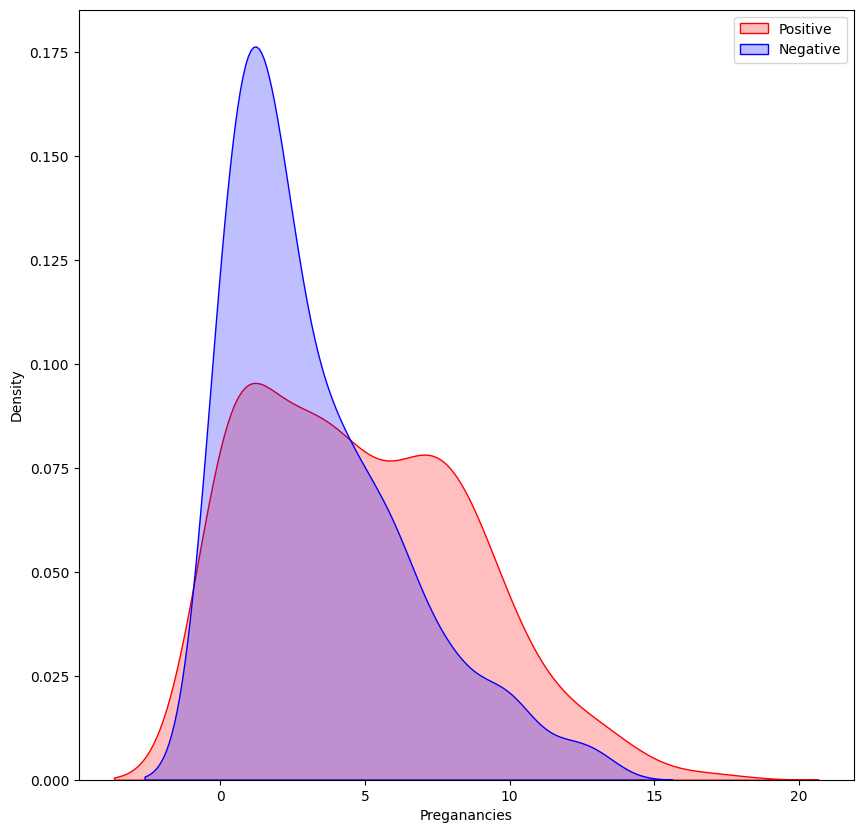

In [6]:
plt.figure(figsize=(10, 10))
kde = sns.kdeplot(data["Pregnancies"][data["Outcome"]==1], color="red", shade=True)
kde = sns.kdeplot(data["Pregnancies"][data["Outcome"]==0], color="blue", shade=True)
kde.set_xlabel("Preganancies")
kde.set_ylabel("Density")
kde.legend(["Positive", "Negative"])

<body>Exploring Glucose and target variable</body>

<Axes: xlabel='Outcome', ylabel='Glucose'>

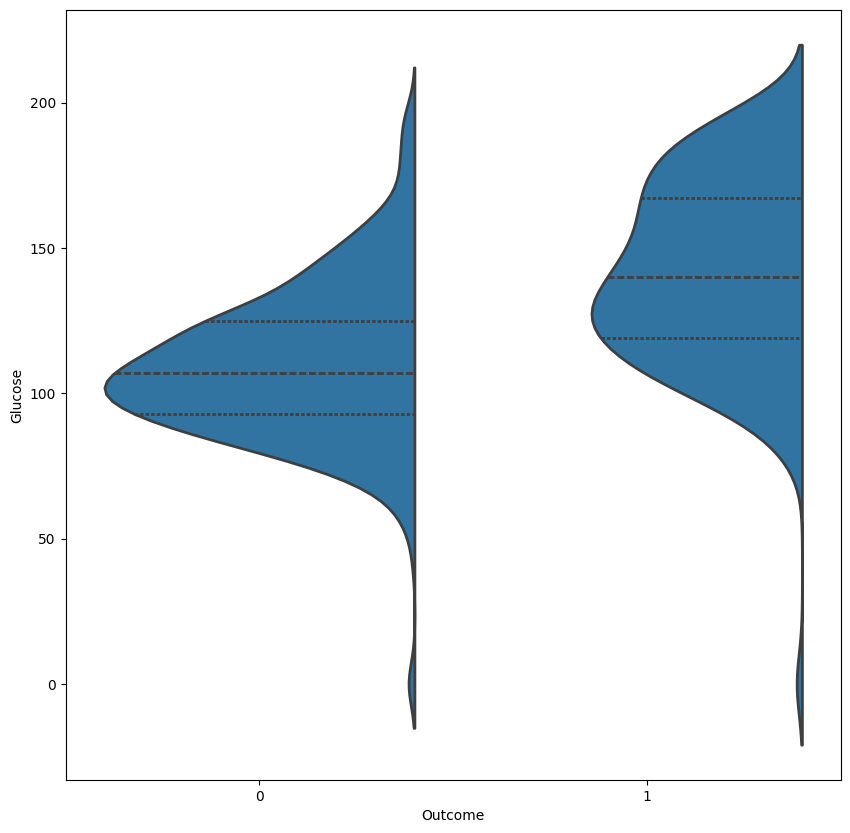

In [7]:
plt.figure(figsize=(10, 10))
sns.violinplot(data=data, x="Outcome", y="Glucose", split=True, linewidth=2, inner="quart")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_24036\1199214043.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kde = sns.kdeplot(data["Glucose"][data["Outcome"]==1], color="red", shade=True)
C:\Users\ASUS\AppData\Local\Temp\ipykernel_24036\1199214043.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  kde = sns.kdeplot(data["Glucose"][data["Outcome"]==0], color="blue", shade=True)


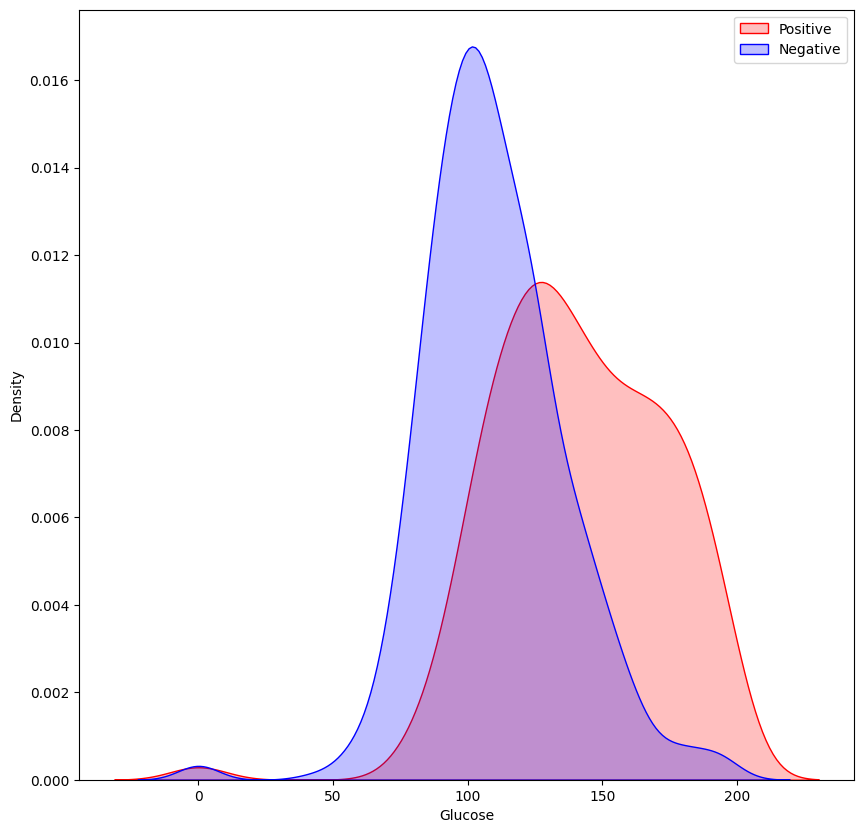

In [8]:
plt.figure(figsize=(10, 10))
kde = sns.kdeplot(data["Glucose"][data["Outcome"]==1], color="red", shade=True)
kde = sns.kdeplot(data["Glucose"][data["Outcome"]==0], color="blue", shade=True)
kde.set_xlabel("Glucose")
kde.set_ylabel("Density")
kde.legend(["Positive", "Negative"])

In [9]:
cols = ["Glucose", "BloodPressure", "BMI", "SkinThickness", "Insulin"]
for col in cols:
    data[col] = data[col].replace(0, data[col].median())

In [10]:
X = data.drop("Outcome", axis=1)
y = data["Outcome"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [12]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [13]:
training_accuracy = []
test_accuracy = []
for n_neighbors in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=n_neighbors)
    knn.fit(X_train, y_train)

    training_accuracy.append(knn.score(X_train, y_train))
    test_accuracy.append(knn.score(X_test, y_test))

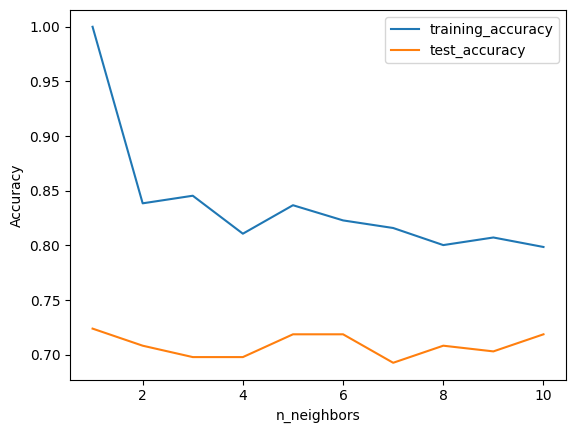

In [14]:
plt.plot(range(1, 11), training_accuracy, label="training_accuracy")
plt.plot(range(1, 11), test_accuracy, label = "test_accuracy")
plt.ylabel("Accuracy")
plt.xlabel("n_neighbors")
plt.legend()

In [15]:
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(X_train, y_train)
print(f"{knn.score(X_train, y_train)}: Training Accuracy")
print(f"{knn.score(X_test, y_test)}: Test Accuracy")

0.8072916666666666: Training Accuracy
0.703125: Test Accuracy


In [16]:
dt = DecisionTreeClassifier(random_state=0)
dt.fit(X_train, y_train)
print(f"{dt.score(X_train, y_train)}: Training Accuracy")
print(f"{dt.score(X_test, y_test)}: Test Accuracy")

1.0: Training Accuracy
0.7135416666666666: Test Accuracy


In [17]:
dt1 = DecisionTreeClassifier(random_state=0, max_depth=3)
dt1.fit(X_train, y_train)
print(f"{dt1.score(X_train, y_train)}: Training Accuracy")
print(f"{dt1.score(X_test, y_test)}: Test Accuracy")

0.7916666666666666: Training Accuracy
0.7135416666666666: Test Accuracy


In [18]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print(f"{lr.score(X_train, y_train)}: Training Accuracy")
print(f"{lr.score(X_test, y_test)}: Test Accuracy")

0.7881944444444444: Training Accuracy
0.7395833333333334: Test Accuracy


In [19]:
rf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42)
rf.fit(X_train, y_train)
print(f"{rf.score(X_train, y_train)}: Training Accuracy")
print(f"{rf.score(X_test, y_test)}: Test Accuracy")

0.8663194444444444: Training Accuracy
0.7395833333333334: Test Accuracy


In [20]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.77      0.86      0.81       125
           1       0.66      0.52      0.58        67

    accuracy                           0.74       192
   macro avg       0.72      0.69      0.70       192
weighted avg       0.73      0.74      0.73       192

ROC-AUC: 0.8195820895522388


In [21]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=5, scoring="roc_auc")
grid.fit(X_train, y_train)

print(grid.best_params_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}


In [22]:
mlp = MLPClassifier(random_state=0)
mlp.fit(X_train, y_train)
print(f"{mlp.score(X_train, y_train)}: Training Accuracy")
print(f"{mlp.score(X_test, y_test)}: Testing Accuracy")

0.8246527777777778: Training Accuracy
0.703125: Testing Accuracy


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [23]:
mlp1 = MLPClassifier(random_state=0)
mlp1.fit(X_train, y_train)
print(f"{mlp1.score(X_train, y_train)}: Training Accuracy")
print(f"{mlp1.score(X_test, y_test)}: Test Accuracy")

0.8246527777777778: Training Accuracy
0.703125: Test Accuracy


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


In [24]:
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

print("XGB Train:", xgb.score(X_train, y_train))
print("XGB Test:", xgb.score(X_test, y_test))

XGB Train: 0.9774305555555556
XGB Test: 0.7447916666666666


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:11:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [25]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft'   # IMPORTANT (uses probabilities)
)

ensemble.fit(X_train, y_train)

print("Ensemble Train:", ensemble.score(X_train, y_train))
print("Ensemble Test:", ensemble.score(X_test, y_test))

Ensemble Train: 0.8923611111111112
Ensemble Test: 0.7395833333333334


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:11:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [26]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf),
        ('xgb', xgb)
    ],
    voting='soft',
    weights=[1, 2, 3]   # XGB highest weight
)

ensemble.fit(X_train, y_train)

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:11:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 2, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [27]:
y_pred = ensemble.predict(X_test)
y_prob = ensemble.predict_proba(X_test)[:, 1]

In [28]:
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.79      0.82      0.80       125
           1       0.64      0.58      0.61        67

    accuracy                           0.74       192
   macro avg       0.71      0.70      0.71       192
weighted avg       0.73      0.74      0.74       192

ROC-AUC: 0.8223283582089552


In [29]:
rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 5, 7, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ['sqrt', 'log2', None]
}

rf_random = RandomizedSearchCV(
    rf,
    rf_param_grid,
    n_iter=25,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

rf_random.fit(X_train, y_train)

print("Best RF Params:", rf_random.best_params_)
rf_best = rf_random.best_estimator_

Best RF Params: {'n_estimators': 500, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 5}


In [30]:
xgb = XGBClassifier(
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

xgb_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "gamma": [0, 0.1, 0.2],
    "min_child_weight": [1, 3, 5]
}

xgb_random = RandomizedSearchCV(
    xgb,
    xgb_param_grid,
    n_iter=30,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1,
    random_state=42
)

xgb_random.fit(X_train, y_train)

print("Best XGB Params:", xgb_random.best_params_)
xgb_best = xgb_random.best_estimator_

Best XGB Params: {'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.01, 'gamma': 0.2, 'colsample_bytree': 0.8}


c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:11:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [31]:
lr = LogisticRegression(max_iter=1000)

lr_param_grid = {
    "C": [0.01, 0.1, 1, 10, 100],
    "penalty": ['l2'],
    "solver": ['lbfgs']
}

lr_random = RandomizedSearchCV(
    lr,
    lr_param_grid,
    n_iter=10,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

lr_random.fit(X_train, y_train)

lr_best = lr_random.best_estimator_

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_search.py:324: UserWarning: The total space of parameters 5 is smaller than n_iter=10. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [32]:
ensemble = VotingClassifier(
    estimators=[
        ('lr', lr_best),
        ('rf', rf_best),
        ('xgb', xgb_best)
    ],
    voting='soft',
    weights=[1, 2, 4]   # prioritize XGB
)

ensemble.fit(X_train, y_train)

c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\ASUS\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:11:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"estimators estimators: list of (str, estimator) tuplesInvoking the ``fit`` method on the ``VotingClassifier`` will fit clonesof those original estimators that will be stored in the class attribute``self.estimators_``. An estimator can be set to ``'drop'`` using:meth:`set_params`... versionchanged:: 0.21 ``'drop'`` is accepted. Using None was deprecated in 0.22 and support was removed in 0.24.","[('lr', ...), ('rf', ...), ...]"
,"voting voting: {'hard', 'soft'}, default='hard'If 'hard', uses predicted class labels for majority rule voting.Else if 'soft', predicts the class label based on the argmax ofthe sums of the predicted probabilities, which is recommended foran ensemble of well-calibrated classifiers.",'soft'
,"weights weights: array-like of shape (n_classifiers,), default=NoneSequence of weights (`float` or `int`) to weight the occurrences ofpredicted class labels (`hard` voting) or class probabilitiesbefore averaging (`soft` voting). Uses uniform weights if `None`.","[1, 2, ...]"
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for ``fit``.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionadded:: 0.18",None
,"flatten_transform flatten_transform: bool, default=TrueAffects shape of transform output only when voting='soft'If voting='soft' and flatten_transform=True, transform method returnsmatrix with shape (n_samples, n_classifiers * n_classes). Ifflatten_transform=False, it returns(n_classifiers, n_samples, n_classes).",True
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting will be printed as itis completed... versionadded:: 0.23",False
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001


In [33]:
y_pred = ensemble.predict(X_test)
y_prob = ensemble.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("Final ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.75      0.88      0.81       125
           1       0.67      0.46      0.55        67

    accuracy                           0.73       192
   macro avg       0.71      0.67      0.68       192
weighted avg       0.73      0.73      0.72       192

Final ROC-AUC: 0.8273432835820895
